# Prac 07.2

This notebook inspects the extracted GTSRB training split: random samples, per-class histogram, and additional analysis of resolution and brightness.

In [1]:
from pathlib import Path
from collections import Counter
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]
ROOT = Path('..') / 'data' / 'GTSRB' / 'Training'
print('Dataset root:', ROOT.resolve())
print('Exists:', ROOT.exists())

Dataset root: C:\Users\98389\Downloads\Computer-vision\Prac_07\Prac 07.2\data\GTSRB\Training
Exists: True


In [2]:
records = []
for class_dir in sorted(ROOT.glob('*')):
    if not class_dir.is_dir():
        continue
    csv_path = class_dir / f'GT-{class_dir.name}.csv'
    df = pd.read_csv(csv_path, sep=';')
    df['ClassId'] = int(class_dir.name)
    df['Path'] = df['Filename'].apply(lambda name: str(class_dir / name))
    records.append(df[['Path', 'Width', 'Height', 'ClassId']])

data = pd.concat(records, ignore_index=True)
num_samples = len(data)
print('Number of training samples:', num_samples)
data.head()

Number of training samples: 26640


,Path,Width,Height,ClassId
0,..\data\GTSRB\Training\00000\00000_00000.ppm,29,30,0
1,..\data\GTSRB\Training\00000\00000_00001.ppm,30,30,0
2,..\data\GTSRB\Training\00000\00000_00002.ppm,30,30,0
3,..\data\GTSRB\Training\00000\00000_00003.ppm,31,31,0
4,..\data\GTSRB\Training\00000\00000_00004.ppm,30,32,0


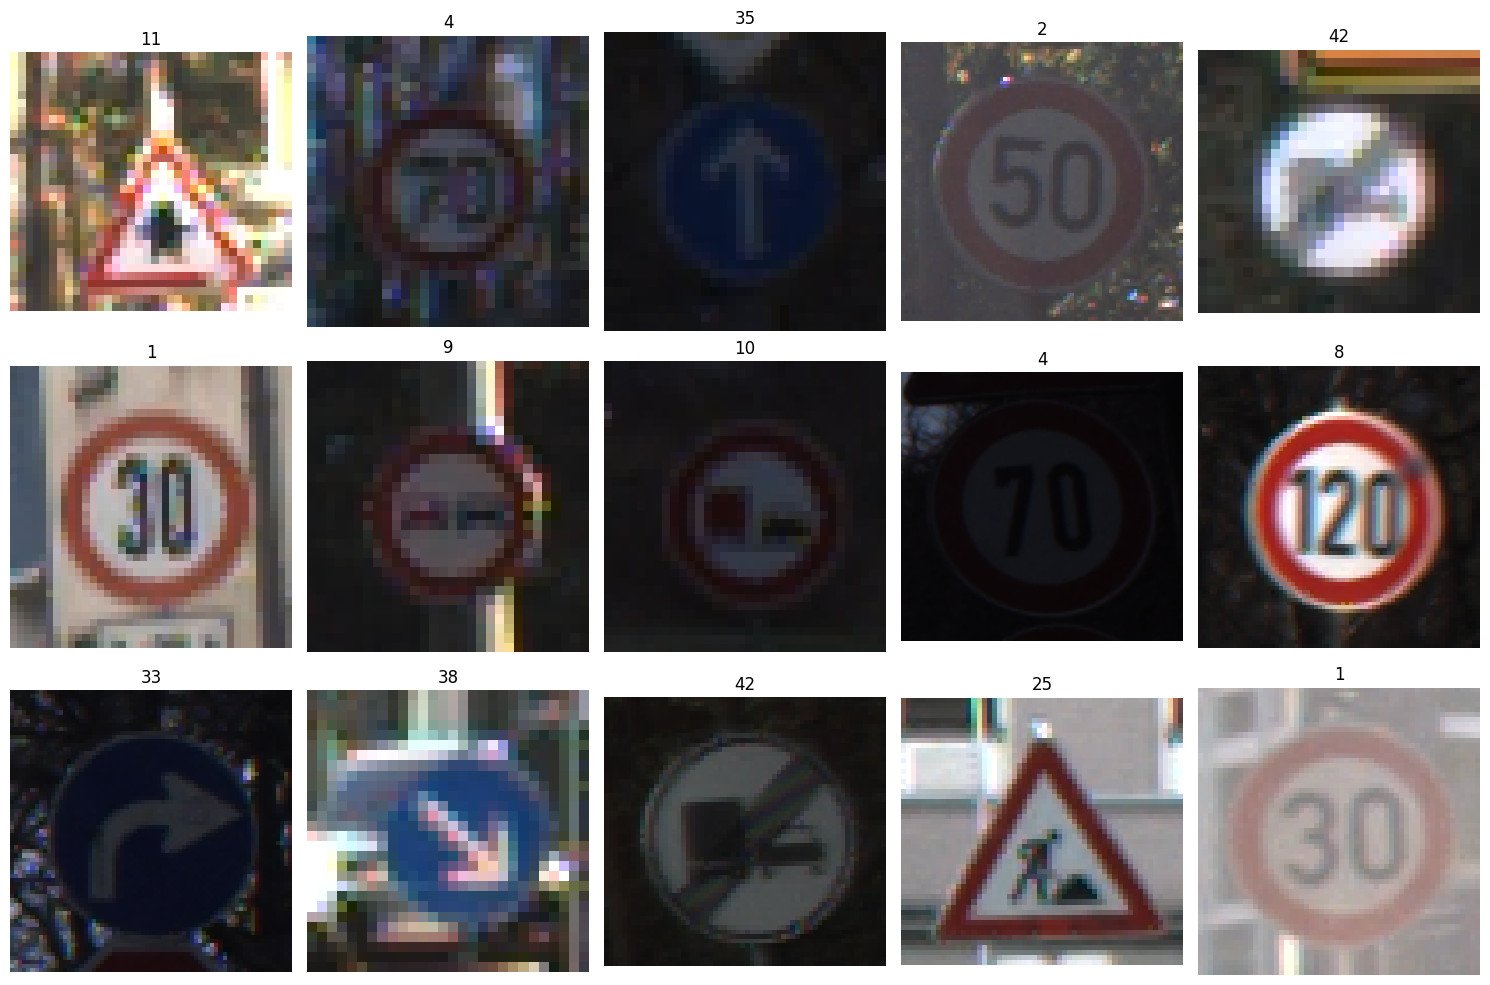

In [3]:
for ii in range(15):
    idx = np.random.randint(0, num_samples)
    img = cv2.imread(data.iloc[idx]['Path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 5, ii + 1), plt.imshow(img), plt.title(int(data.iloc[idx]['ClassId']))
    plt.axis('off')
plt.tight_layout()
plt.show()

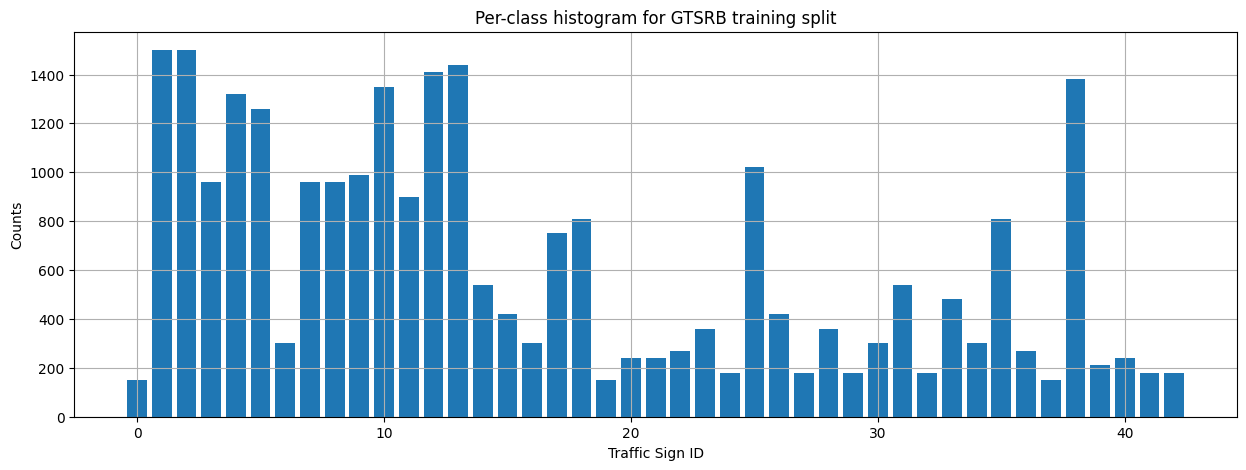

Least represented classes: [(np.int64(0), 150), (np.int64(19), 150), (np.int64(37), 150), (np.int64(24), 180), (np.int64(27), 180)]
Most represented classes: [(np.int64(38), 1380), (np.int64(12), 1410), (np.int64(13), 1440), (np.int64(1), 1500), (np.int64(2), 1500)]


In [4]:
ids = data['ClassId'].to_numpy()
hist = Counter(ids)
plt.figure(figsize=(15, 5))
plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')
plt.title('Per-class histogram for GTSRB training split')
plt.show()

sorted_counts = sorted(hist.items(), key=lambda kv: kv[1])
print('Least represented classes:', sorted_counts[:5])
print('Most represented classes:', sorted_counts[-5:])

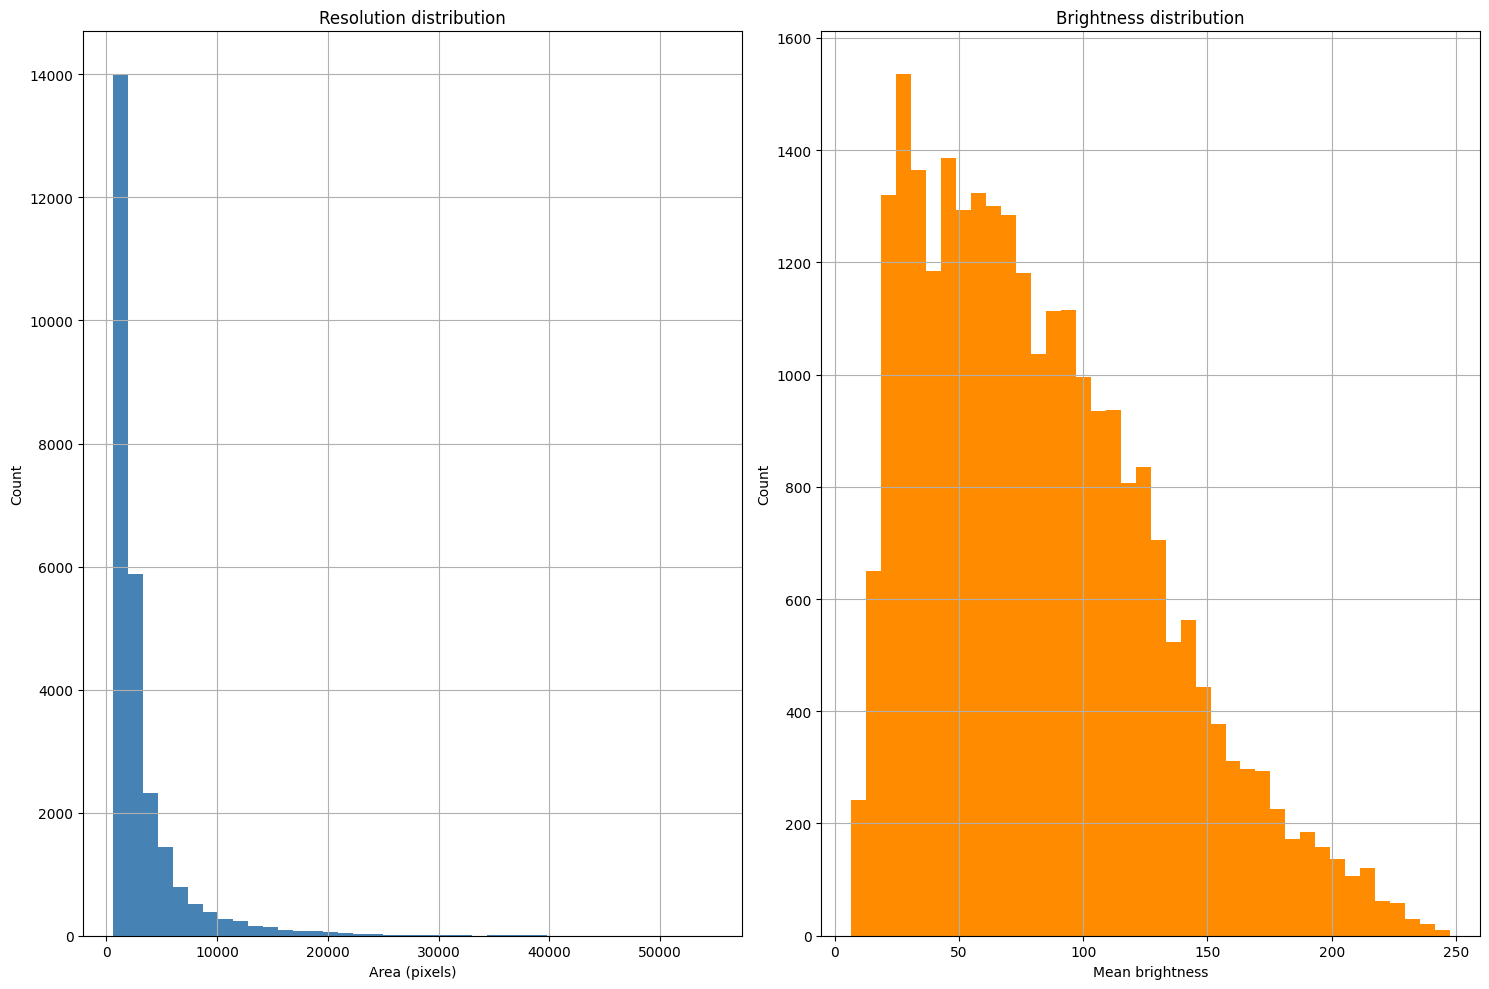

Darkest classes (avg brightness):
ClassId
6     39.381205
8     44.560304
10    53.044580
5     60.958211
7     61.037614
Name: MeanBrightness, dtype: float64

Brightest classes (avg brightness):
ClassId
34    109.174246
16    109.203596
14    120.918527
35    124.823507
0     131.604891
Name: MeanBrightness, dtype: float64


In [5]:
data['Area'] = data['Width'] * data['Height']
data['MeanBrightness'] = [cv2.imread(path).mean() for path in data['Path']]

plt.subplot(121)
plt.hist(data['Area'], bins=40, color='steelblue')
plt.grid(True)
plt.xlabel('Area (pixels)')
plt.ylabel('Count')
plt.title('Resolution distribution')

plt.subplot(122)
plt.hist(data['MeanBrightness'], bins=40, color='darkorange')
plt.grid(True)
plt.xlabel('Mean brightness')
plt.ylabel('Count')
plt.title('Brightness distribution')
plt.tight_layout()
plt.show()

class_brightness = data.groupby('ClassId')['MeanBrightness'].mean().sort_values()
print('Darkest classes (avg brightness):')
print(class_brightness.head())
print('\nBrightest classes (avg brightness):')
print(class_brightness.tail())

### Questions

The dataset is only moderately balanced: every class is represented, but the class counts still vary noticeably. Some signs have substantially more examples than others, so training on the raw distribution would expose the model to a mild class imbalance. The optional analysis also shows that both resolution and brightness vary a lot, which means preprocessing and augmentation matter before training a robust classifier.